[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AstroAI-CfA/tutorial-lsdb/blob/main/tutorials/Notebook_2_Crossmatch.ipynb)

Author: Konstantin Malanchev and the LINCC Frameworks team

Last updated: June 2026

# LSDB: Cross-Matching Gaia DR3 × APOGEE DR17 with Streaming

In this notebook we'll learn how to:
- Load two catalogs from different cloud sources (AWS S3 and HuggingFace)
- Cross-match them spatially with LSDB
- Use LSDB's streaming interface (`CatalogStream`) to process the cross-matched catalog partition-by-partition
- Build an animated Hertzsprung-Russell diagram (absolute Gaia G magnitude vs APOGEE effective temperature) that updates as each chunk of data arrives

In [1]:
# # do you need to install the packages?
# # if yes, uncomment the line below and restart the kernel
# %pip install -U lsdb s3fs huggingface_hub tqdm

In [2]:
import io
import logging
import os
from pathlib import Path
import warnings

# Must be set before importing packages that use numexpr
os.environ["NUMEXPR_MAX_THREADS"] = "2"

import dask
import lsdb
import matplotlib as mpl
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
from dask.distributed import Client
from IPython.display import display, Image as IPImage
from lsdb.streams import CatalogStream
from matplotlib import rcParams
from PIL import Image
from tqdm.auto import tqdm

%matplotlib inline

warnings.simplefilter("ignore")
logging.getLogger("numexpr.utils").setLevel(logging.WARNING)
logging.getLogger("distributed").setLevel(logging.WARNING)
rcParams["savefig.dpi"] = 550
rcParams["font.size"] = 20
plt.rc("font", family="serif")
mpl.rcParams["axes.linewidth"] = 2
dask.config.set({"dataframe.convert-string": False})

print(f"Version of lsdb is {lsdb.__version__}")

Version of lsdb is 0.9.2


## Setup Dask cluster

In [3]:
client = Client(n_workers=2, memory_limit="4GiB", threads_per_worker=1)
print(f"Dask is running at: {client.dashboard_link}")

Dask is running at: http://127.0.0.1:8787/status


## Load the Catalogs

We load two catalogs lazily:

1. **Gaia DR3** from the STScI public S3 bucket. We keep only stars with well-measured parallaxes (`parallax_over_error > 30`). The absolute G magnitude is computed from the parallax $\varpi$ (in mas):

$$G_{\rm abs} = G + 5\log_{10}(\varpi) - 10$$

2. **APOGEE DR17** (from the Multimodal Universe collection on HuggingFace). APOGEE is an infrared spectroscopic survey of Milky Way stars; for each star it provides spectroscopically derived stellar parameters including the effective temperature `teff` and metallicity `fe_h`.


Gaia partitions: 2016


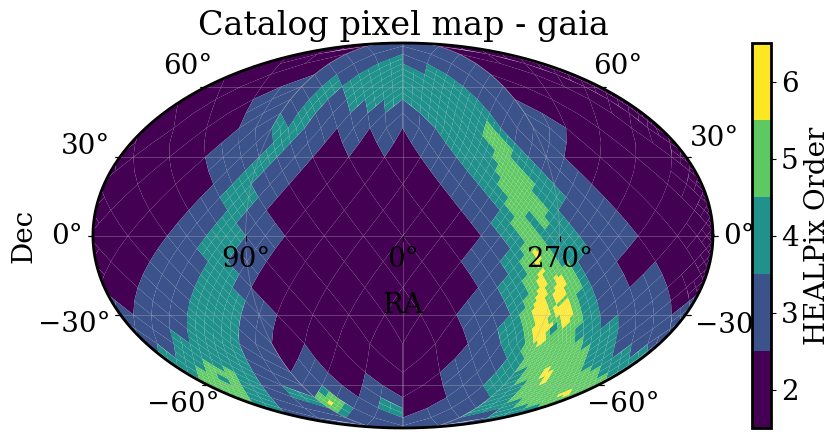

In [4]:
gaia = lsdb.open_catalog(
    "s3://stpubdata/gaia/gaia_dr3/public/hats",
    columns=["parallax", "parallax_over_error", "phot_g_mean_mag", "bp_rp"],
).query("parallax_over_error > 30 and parallax > 0 and -2 < bp_rp < 6")

# Compute abs_g lazily
gaia = gaia.map_partitions(
    lambda df: df.assign(
        abs_g=df["phot_g_mean_mag"] + 5 * np.log10(df["parallax"]) - 10,
    ),
)
gaia.plot_pixels()
print(f"Gaia partitions: {gaia.npartitions}")

APOGEE partitions: 1820


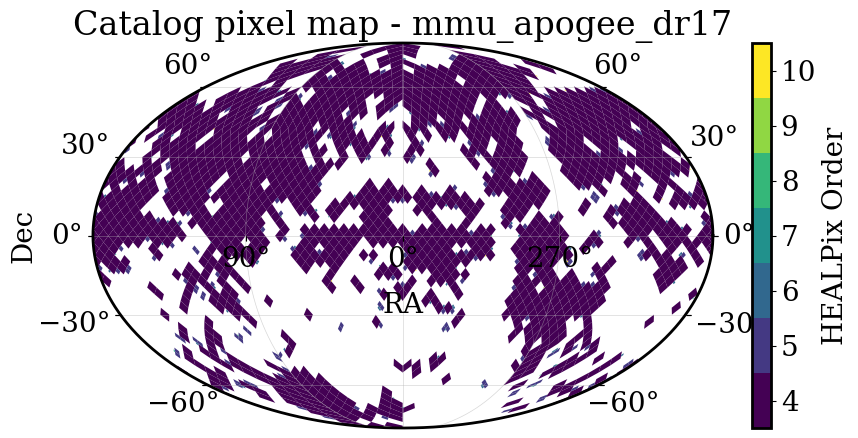

In [5]:
apogee = lsdb.open_catalog(
    "hf://datasets/hugging-science/mmu_apogee_dr17/mmu_apogee_dr17",
    columns=["teff", "teff_err", "fe_h"],
).query("teff > 0 and teff_err < 100 and not fe_h.isna()")
apogee.plot_pixels()
print(f"APOGEE partitions: {apogee.npartitions}")

## Cross-Match

`catalog.crossmatch()` spatially joins two HATS catalogs partition-by-partition using a KD-tree to find the nearest APOGEE neighbour within `radius_arcsec` for each Gaia source.

With `suffix_method="overlapping_columns"` only the columns present in both catalogs (`ra` and `dec`) get suffixed; unique columns like `parallax`, `phot_g_mean_mag`, and `teff` keep their original names.

In [6]:
xmatch = gaia.crossmatch(
    apogee,
    radius_arcsec=0.5,
    suffixes=("_gaia", "_apogee"),
    suffix_method="overlapping_columns",
)

xmatch

+--------+---------------------+------------------------+
| Column | Left (suffix=_gaia) | Right (suffix=_apogee) |
+--------+---------------------+------------------------+
|   ra   |       ra_gaia       |       ra_apogee        |
|  dec   |      dec_gaia       |       dec_apogee       |
+--------+---------------------+------------------------+


,parallax,parallax_over_error,phot_g_mean_mag,bp_rp,ra_gaia,dec_gaia,abs_g,teff,teff_err,fe_h,ra_apogee,dec_apogee,_dist_arcsec
npartitions=2320,,,,,,,,,,,,,
"Order: 4, Pixel: 0",double[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow]
"Order: 7, Pixel: 234",...,...,...,...,...,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
"Order: 4, Pixel: 3070",...,...,...,...,...,...,...,...,...,...,...,...,...
"Order: 4, Pixel: 3071",...,...,...,...,...,...,...,...,...,...,...,...,...


## Previewing the cross-match results

Let's take a look over the first few rows of the cross-matched catalog. `.head()` method would run all the computations we planned so far and return a dataframe with the first few rows of the cross-matched catalog.

In [7]:
xmatch.head(10)

,parallax,parallax_over_error,phot_g_mean_mag,bp_rp,ra_gaia,dec_gaia,abs_g,teff,teff_err,fe_h,ra_apogee,dec_apogee,_dist_arcsec
_healpix_29,,,,,,,,,,,,,
1429961381878,2.676207,141.377151,12.356248,0.810369,45.132144,0.137854,4.493846,5816.728516,35.889587,-0.41911,45.132108,0.137814,0.193546
1668455529344,1.772803,113.170563,12.511697,1.224066,45.058168,0.127402,3.755,4926.416992,8.640204,0.17621,45.058113,0.127478,0.338502
6652405090064,3.148076,160.876465,10.789548,0.618286,45.086156,0.248825,3.279774,6382.359375,44.05798,-0.004231,45.086141,0.248842,0.080936
7771460584591,4.595412,95.697823,12.529439,1.141436,45.204601,0.327126,5.841061,4817.820801,13.609303,-0.10967,45.204469,0.327165,0.495371
7879400591715,1.40766,74.293739,10.253987,1.154534,45.136038,0.335043,0.996477,5116.177734,10.694522,-0.11741,45.13603,0.335007,0.133077
8508837297929,2.31411,123.657837,12.748305,0.834274,45.138348,0.399185,4.570225,5945.791016,45.097248,-0.46992,45.138386,0.399188,0.136403
8587796498290,1.661167,99.911964,12.165601,0.901805,45.172877,0.403601,3.267667,5793.415527,28.072327,-0.032658,45.172837,0.403595,0.145402
10900776543811,2.179118,134.213654,12.96874,0.942316,44.87286,0.332085,4.660145,5644.835938,25.008944,0.097394,44.87281,0.332157,0.314578
21471020495706,2.404952,162.684052,12.505317,0.830778,45.319795,0.506154,4.410849,5966.295898,32.380981,-0.040308,45.319716,0.506211,0.350421


## HR Diagram: Absolute G vs Effective Temperature

With the x-axis inverted (hot stars on the left, cool on the right) this reproduces the classic Hertzsprung-Russell diagram. Stars are colored by their APOGEE metallicity [Fe/H].

## Streaming HR Diagram with `CatalogStream`

`CatalogStream` processes `partitions_per_chunk` partitions at a time, pre-fetching in the background while we handle the current chunk. We use it to build the HR diagram incrementally, capturing a frame after each chunk.

> **Tip:** `xmatch.partitions[:25]` limits streaming to the first 25 partitions, which is useful for debugging. Remove the slice to stream the full catalog.

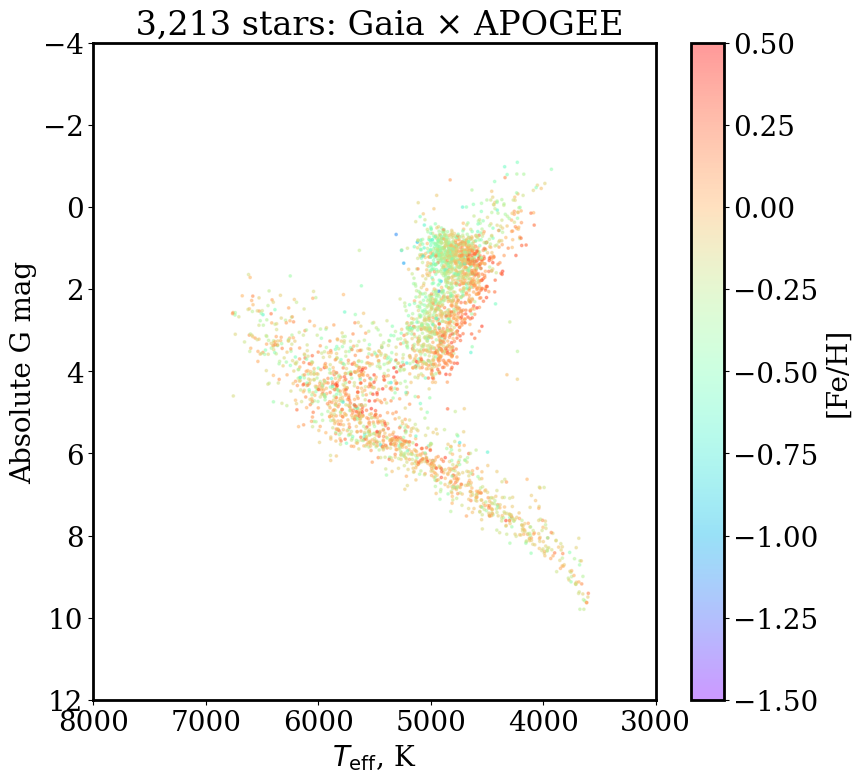

0it [00:15, ?it/s]

Total matched stars plotted: 3,213
CPU times: user 7.63 s, sys: 2.24 s, total: 9.87 s
Wall time: 3min 55s


In [8]:
%%time

frames = []
all_teff = []
all_abs_g = []
all_fe_h = []

cmap = "rainbow"
norm = mcolors.Normalize(vmin=-1.5, vmax=0.5)

fig, ax = plt.subplots(figsize=(9, 8))
ax.set_xlim(8000, 3000)
ax.set_ylim(12, -4)
ax.set_xlabel(r"$T_{\rm eff}$, K")
ax.set_ylabel("Absolute G mag")
scatter = ax.scatter([], [], s=3, alpha=0.4, c=np.array([]), cmap=cmap, norm=norm, rasterized=True)
fig.colorbar(scatter, ax=ax, label="[Fe/H]")
plt.tight_layout()
fig_handle = display(fig, display_id=True)

# partitions_per_chunk should be at least the number of Dask workers so all workers stay busy
stream = CatalogStream(xmatch.partitions[:25], partitions_per_chunk=2, seed=42)

for chunk in tqdm(stream):
    all_teff.extend(chunk["teff"].tolist())
    all_abs_g.extend(chunk["abs_g"].tolist())
    all_fe_h.extend(chunk["fe_h"].tolist())

    scatter.set_offsets(np.column_stack([all_teff, all_abs_g]))
    scatter.set_array(np.array(all_fe_h))
    ax.set_title(f"{len(all_abs_g):6,d} stars: Gaia × APOGEE")

    fig_handle.update(fig)

    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=80)
    buf.seek(0)
    frames.append(Image.open(buf).copy())
    buf.close()

plt.close(fig)
print(f"Total matched stars plotted: {len(all_abs_g):,}")

## Save and Display the Animation

We use Pillow to save the captured frames as an animated GIF.

In [9]:
gif_path = Path("images") / "hr_diagram_streaming.gif"
gif_path.parent.mkdir(exist_ok=True)

if frames:
    frames[0].save(
        gif_path,
        save_all=True,
        append_images=frames[1:],
        duration=350,
        loop=0,
    )
    print(f"Saved {len(frames)}-frame GIF -> {gif_path}")
else:
    print("No frames captured -- check that the cross-match returned results.")

Saved 13-frame GIF -> images/hr_diagram_streaming.gif


In [10]:
client.close()

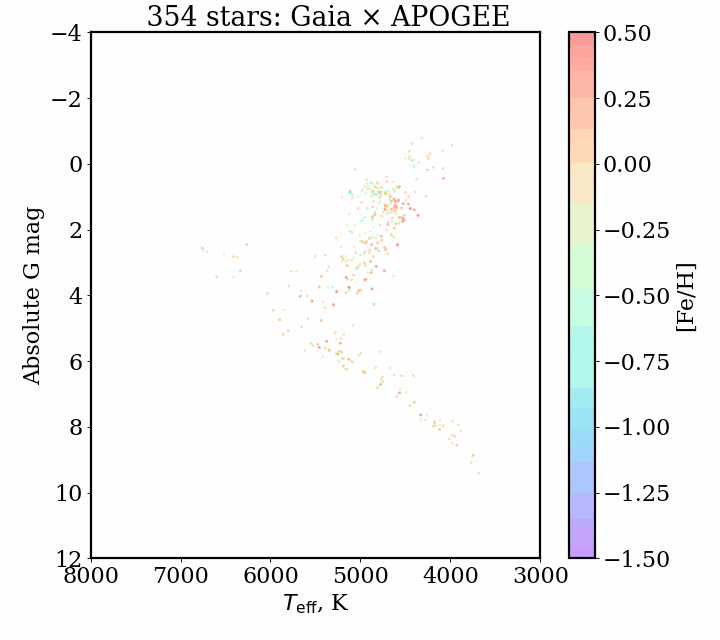

In [11]:
IPImage(filename=gif_path)

## Problem 2: Predict $T_{\rm eff}$ from Photometric Colors

The cross-matched catalog pairs each star's APOGEE spectroscopic temperature with its
Gaia and APOGEE photometric colors.

**Your task:** train a model on the streaming cross-match to predict `teff` from
Gaia and APOGEE colors.

**Steps:**
1. Use the `xmatch` catalog already built above. Features: the Gaia colors `bp_rp`
   ($G_{\rm BP} - G_{\rm RP}$) and `g_rp` ($G - G_{\rm RP}$), plus the APOGEE $J - H$
   color computed from `j` and `h`. Target: `teff`.
2. Stream `xmatch` with `CatalogStream`. Hold a few partitions out as a test set;
   train on all remaining partitions.
3. After streaming, predict on the test set and plot predicted vs APOGEE $T_{\rm eff}$.
   Report MAE.

**Advanced:** add the absolute $G$ magnitude (from `phot_g_mean_mag` and `parallax`) as a fourth feature. Does it improve the predictions?

One possible solution is in `Notebook_2_Solution.ipynb`.